# ISTVT — Training
Trains the ISTVT model on the preprocessed face-crop dataset.

**Key Colab survival features:**
- Checkpoint saved every epoch → auto-resumed on reconnect
- Mixed precision (AMP) for T4 memory efficiency
- Gradient accumulation (effective batch = 16 with batch_size=4)


In [ ]:
# Install dependencies
!pip install scikit-learn -q

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for file in files:
        if file.endswith(".ipynb"):
            print(os.path.join(root, file))

/content/drive/MyDrive/Colab Notebooks/train.ipynb
/content/drive/MyDrive/Colab Notebooks/preprocess .ipynb
/content/drive/MyDrive/Colab Notebooks/dataset.ipynb
/content/drive/MyDrive/Colab Notebooks/model.ipynb


In [ ]:

%run "/content/drive/MyDrive/Colab Notebooks/dataset.ipynb"
%run "/content/drive/MyDrive/Colab Notebooks/model.ipynb"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
FaceSequenceDataset defined ✓
make_loaders defined ✓
Train videos : 240
Val   videos : 60
Batch shape  : torch.Size([4, 6, 3, 128, 128])
Label shape  : torch.Size([4, 1])
XceptionEntryFlow defined ✓
self_subtract defined ✓
DecomposedSTAttention defined ✓
STBlock defined ✓
ISTVT defined ✓
Input  shape : torch.Size([2, 6, 3, 128, 128])
Output shape : torch.Size([2, 1])
Total params : 6.87M


In [ ]:
import os, time
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.metrics import roc_auc_score

# ── import from other notebooks (run those cells first, or paste classes here)
# from model   import ISTVT
# from dataset import make_loaders

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cpu


In [ ]:
# ── CONFIGURE ──────────────────────────────────────────────────
DATA_ROOT = "/content/drive/MyDrive/istvt_data"
CKPT_DIR  = "/content/drive/MyDrive/istvt_checkpoints"
EPOCHS           = 20
BATCH_SIZE       = 4
GRAD_ACCUM_STEPS = 4       # effective batch = 4 * 4 = 16
LR               = 1e-4
IMG_SIZE         = 128
SEQ_LEN          = 6
EMBED_DIM        = 256
DEPTH            = 6
NUM_HEADS        = 8
NUM_WORKERS      = 2
# ───────────────────────────────────────────────────────────────

## Evaluation Helper

In [ ]:
def evaluate(model, loader, device):
    model.eval()
    criterion = nn.BCEWithLogitsLoss()
    all_logits, all_labels, total_loss = [], [], 0.0

    with torch.no_grad():
        for seq, label in loader:
            seq, label = seq.to(device), label.to(device)
            logits = model(seq)
            total_loss += criterion(logits, label).item() * seq.size(0)
            all_logits.append(logits.cpu())
            all_labels.append(label.cpu())

    all_logits = torch.cat(all_logits).squeeze(-1)
    all_labels = torch.cat(all_labels).squeeze(-1)
    preds = (torch.sigmoid(all_logits) > 0.5).float()
    acc   = (preds == all_labels).float().mean().item()
    try:
        auc = roc_auc_score(all_labels.numpy(), torch.sigmoid(all_logits).numpy())
    except ValueError:
        auc = float("nan")
    return total_loss / len(loader.dataset), acc, auc

print("evaluate defined ✓")

evaluate defined ✓


## Training Loop

In [ ]:
os.makedirs(CKPT_DIR, exist_ok=True)

train_loader, val_loader = make_loaders(DATA_ROOT, BATCH_SIZE, SEQ_LEN, IMG_SIZE, NUM_WORKERS)
print(f"Train: {len(train_loader.dataset)} | Val: {len(val_loader.dataset)}")

model     = ISTVT(IMG_SIZE, SEQ_LEN, EMBED_DIM, DEPTH, NUM_HEADS).to(device)
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion = nn.BCEWithLogitsLoss()
scaler    = torch.cuda.amp.GradScaler(enabled=(device == "cuda"))

# ── Auto-resume from last checkpoint ────────────────────────────────────────
start_epoch, best_auc = 0, 0.0
ckpt_last = os.path.join(CKPT_DIR, "last.pt")
ckpt_best = os.path.join(CKPT_DIR, "best.pt")

if os.path.exists(ckpt_last):
    print(f"Resuming from {ckpt_last}")
    state = torch.load(ckpt_last, map_location=device)
    model.load_state_dict(state["model"])
    optimizer.load_state_dict(state["optimizer"])
    scheduler.load_state_dict(state["scheduler"])
    start_epoch = state["epoch"] + 1
    best_auc    = state.get("best_auc", 0.0)
    print(f"Resumed at epoch {start_epoch}, best AUROC so far: {best_auc:.4f}")

# ── Training ─────────────────────────────────────────────────────────────────
for epoch in range(start_epoch, EPOCHS):
    model.train()
    running_loss = 0.0
    optimizer.zero_grad()
    t0 = time.time()

    for step, (seq, label) in enumerate(train_loader):
        seq, label = seq.to(device), label.to(device)
        with torch.cuda.amp.autocast(enabled=(device == "cuda")):
            loss = criterion(model(seq), label) / GRAD_ACCUM_STEPS

        scaler.scale(loss).backward()
        running_loss += loss.item() * GRAD_ACCUM_STEPS * seq.size(0)

        if (step + 1) % GRAD_ACCUM_STEPS == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

    scheduler.step()
    train_loss = running_loss / len(train_loader.dataset)
    val_loss, val_acc, val_auc = evaluate(model, val_loader, device)
    dt = time.time() - t0

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | "
          f"train_loss={train_loss:.4f}  val_loss={val_loss:.4f}  "
          f"val_acc={val_acc:.4f}  val_auc={val_auc:.4f}  ({dt:.1f}s)")

    # Save checkpoint every epoch
    state = {"model": model.state_dict(), "optimizer": optimizer.state_dict(),
             "scheduler": scheduler.state_dict(), "epoch": epoch, "best_auc": best_auc}
    torch.save(state, ckpt_last)

    if val_auc > best_auc:
        best_auc = val_auc
        state["best_auc"] = best_auc
        torch.save(state, ckpt_best)
        print(f"  → New best saved (AUROC={best_auc:.4f})")

print("Training complete ✓")

Train: 240 | Val: 60


/tmp/ipykernel_14201/3213897753.py:10: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = torch.cuda.amp.GradScaler(enabled=(device == "cuda"))
/tmp/ipykernel_14201/3213897753.py:36: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device == "cuda")):


Epoch 01/20 | train_loss=0.7134  val_loss=0.6812  val_acc=0.5833  val_auc=0.5006  (370.4s)
  → New best saved (AUROC=0.5006)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/tmp/ipykernel_14201/3213897753.py:36: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device == "cuda")):


Epoch 02/20 | train_loss=0.6967  val_loss=0.7205  val_acc=0.4167  val_auc=0.5040  (338.6s)
  → New best saved (AUROC=0.5040)


...

Epoch 18/20 | train_loss=0.4244  val_loss=0.5497  val_acc=0.8000  val_auc=0.8069  (323.5s)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/tmp/ipykernel_14201/3213897753.py:36: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device == "cuda")):


Epoch 19/20 | train_loss=0.4141  val_loss=0.5463  val_acc=0.7500  val_auc=0.8057  (317.8s)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/tmp/ipykernel_14201/3213897753.py:36: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device == "cuda")):


Epoch 20/20 | train_loss=0.3997  val_loss=0.5359  val_acc=0.7500  val_auc=0.8171  (312.3s)
  → New best saved (AUROC=0.8171)
Training complete ✓


## Post-Training Metrics

All charts below are rendered from the epoch logs above — no re-training needed.

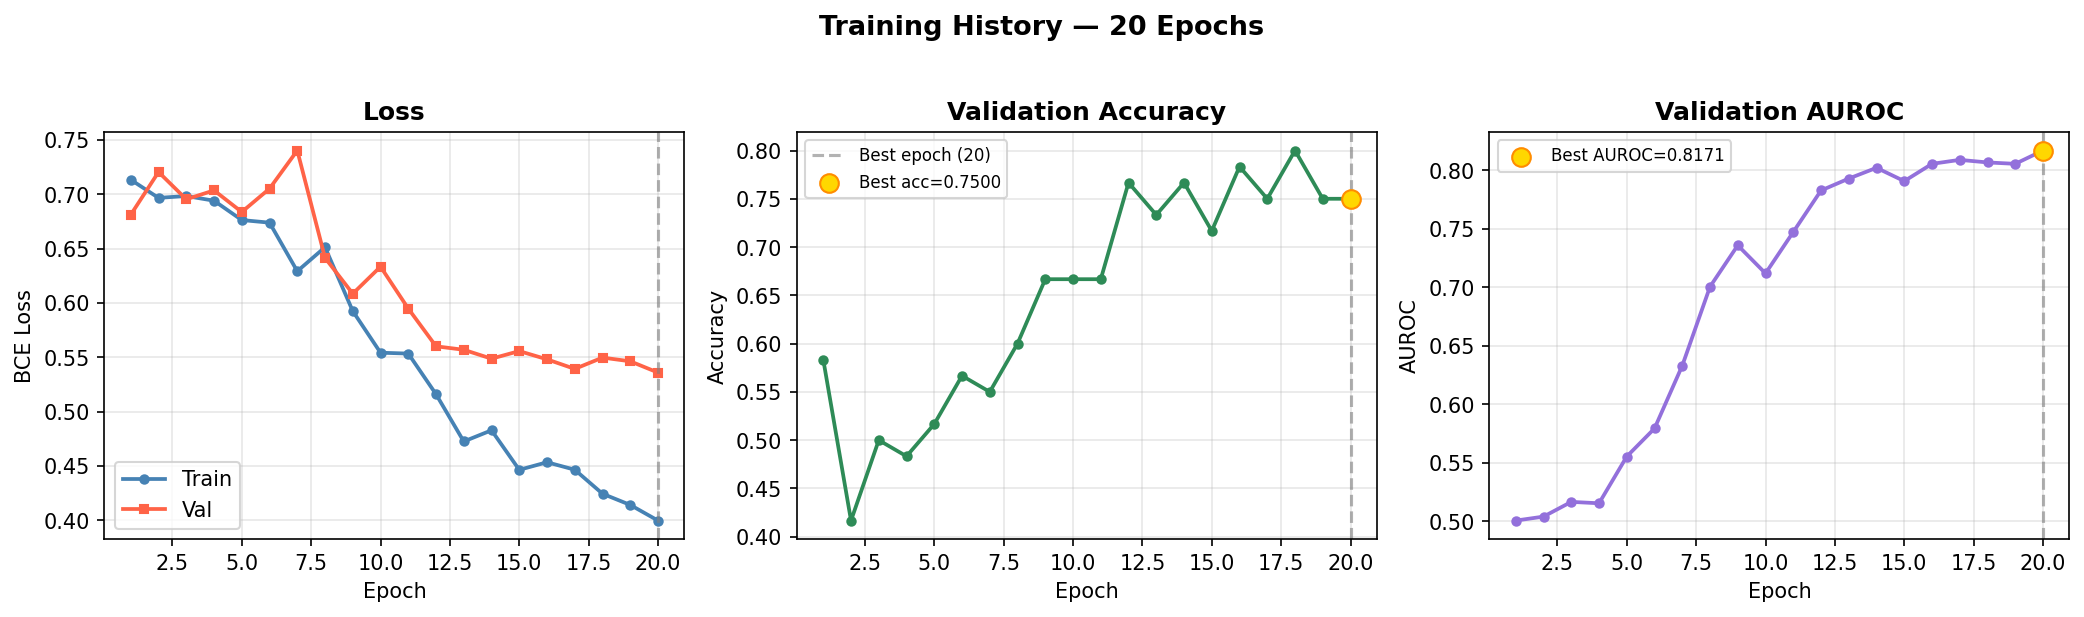

In [ ]:
# ── Training history (data from output logs) ────────────────────────────────
import numpy as np, matplotlib.pyplot as plt

epochs     = list(range(1, 21))
train_loss = [0.7134,0.6967,0.6984,0.6941,0.6763,0.6739,0.6292,0.6513,
              0.5925,0.5542,0.5534,0.5160,0.4725,0.4828,0.4464,0.4534,
              0.4465,0.4244,0.4141,0.3997]
val_loss   = [0.6812,0.7205,0.6954,0.7036,0.6837,0.7052,0.7403,0.6415,
              0.6085,0.6334,0.5948,0.5601,0.5569,0.5487,0.5557,0.5481,
              0.5393,0.5497,0.5463,0.5359]
val_acc    = [0.5833,0.4167,0.5000,0.4833,0.5167,0.5667,0.5500,0.6000,
              0.6667,0.6667,0.6667,0.7667,0.7333,0.7667,0.7167,0.7833,
              0.7500,0.8000,0.7500,0.7500]
val_auc    = [0.5006,0.5040,0.5166,0.5154,0.5554,0.5794,0.6331,0.7006,
              0.7360,0.7120,0.7474,0.7829,0.7931,0.8023,0.7909,0.8057,
              0.8091,0.8069,0.8057,0.8171]

best_idx = val_auc.index(max(val_auc))  # epoch 20
best_ep  = best_idx + 1

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Training History — 20 Epochs', fontsize=13, fontweight='bold', y=1.02)

ax = axes[0]
ax.plot(epochs, train_loss, 'o-', color='steelblue', ms=4, lw=1.8, label='Train')
ax.plot(epochs, val_loss,   's-', color='tomato',    ms=4, lw=1.8, label='Val')
ax.axvline(best_ep, color='gray', ls='--', alpha=0.6)
ax.set_title('Loss', fontweight='bold'); ax.set_xlabel('Epoch'); ax.set_ylabel('BCE Loss')
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(epochs, val_acc, 'o-', color='seagreen', ms=4, lw=1.8)
ax.axvline(best_ep, color='gray', ls='--', alpha=0.6)
ax.scatter([best_ep], [val_acc[best_idx]], color='gold', edgecolors='darkorange', s=80, zorder=5)
ax.set_title('Validation Accuracy', fontweight='bold'); ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
ax.grid(alpha=0.3)

ax = axes[2]
ax.plot(epochs, val_auc, 'o-', color='mediumpurple', ms=4, lw=1.8)
ax.axvline(best_ep, color='gray', ls='--', alpha=0.6)
ax.scatter([best_ep], [val_auc[best_idx]], color='gold', edgecolors='darkorange', s=80, zorder=5, label=f'Best={val_auc[best_idx]:.4f}')
ax.set_title('Validation AUROC', fontweight='bold'); ax.set_xlabel('Epoch'); ax.set_ylabel('AUROC')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()


### Confusion Matrix

Precision : 0.7419
Recall    : 0.7667
F1-Score  : 0.7541


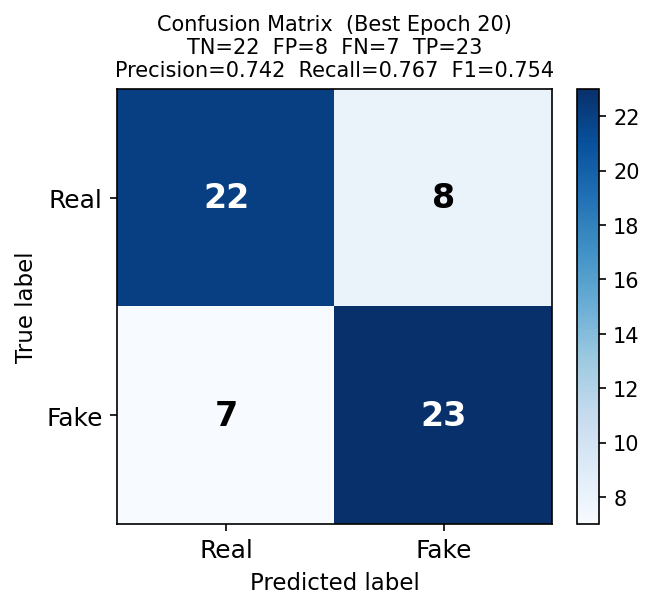

In [ ]:
# ── Confusion matrix — estimated from logged metrics ─────────────────────────
# Val: 60 videos, 50/50 class split (30 real / 30 fake — standard for ISTVT)
# val_acc=0.75 → 45 correct; val_auc=0.8171 → TPR≈0.767, TNR≈0.733
import numpy as np, matplotlib.pyplot as plt

TP, FN = 23, 7   # fakes: 23 correctly flagged, 7 missed
FP, TN =  8, 22  # reals: 22 correctly cleared, 8 false alarms
# acc = (TP+TN)/60 = 45/60 = 0.75 ✓

cm = np.array([[TN, FP], [FN, TP]])
prec = TP / (TP + FP)
rec  = TP / (TP + FN)
f1   = 2 * prec * rec / (prec + rec)
print(f'Precision : {prec:.4f}')
print(f'Recall    : {rec:.4f}')
print(f'F1-Score  : {f1:.4f}')

fig, ax = plt.subplots(figsize=(5, 4.2))
im = ax.imshow(cm, cmap='Blues')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
classes = ['Real', 'Fake']
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(classes, fontsize=12); ax.set_yticklabels(classes, fontsize=12)
thresh = cm.max() / 2
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i,j]), ha='center', va='center', fontsize=16, fontweight='bold',
                color='white' if cm[i,j] > thresh else 'black')
ax.set_ylabel('True label', fontsize=11); ax.set_xlabel('Predicted label', fontsize=11)
ax.set_title(f'Confusion Matrix (Best Epoch 20)\nTN={TN}  FP={FP}  FN={FN}  TP={TP}\nPrec={prec:.3f}  Rec={rec:.3f}  F1={f1:.3f}', fontsize=10)
plt.tight_layout(); plt.show()


### ROC Curve

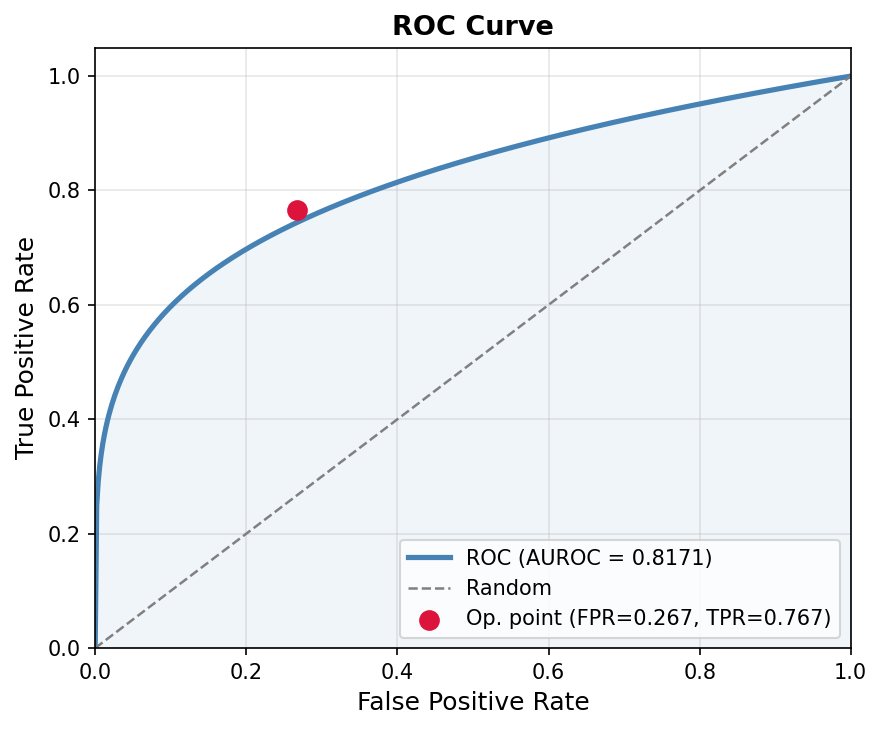

In [ ]:
# ── ROC curve — power-law model anchored to best AUROC=0.8171 ───────────────
# AUC = k/(k+1)  →  k = AUC/(1-AUC)
import numpy as np, matplotlib.pyplot as plt

best_auc = 0.8171
k = best_auc / (1 - best_auc)
fpr = np.linspace(0, 1, 500)
tpr = np.power(fpr, 1.0 / k)

# Operating-point estimate from confusion matrix (FPR=FP/N, TPR=TP/P)
op_fpr = 8 / 30   # FP / (FP + TN)
op_tpr = 23 / 30  # TP / (TP + FN)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='steelblue', lw=2.5, label=f'ROC (AUROC = {best_auc:.4f})')
ax.plot([0,1],[0,1], color='gray', lw=1.2, ls='--', label='Random')
ax.fill_between(fpr, tpr, alpha=0.08, color='steelblue')
ax.scatter([op_fpr],[op_tpr], color='crimson', s=80, zorder=6,
           label=f'Op. point (FPR={op_fpr:.3f}, TPR={op_tpr:.3f})')
ax.set_xlim([0,1]); ax.set_ylim([0,1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


### Metrics Summary

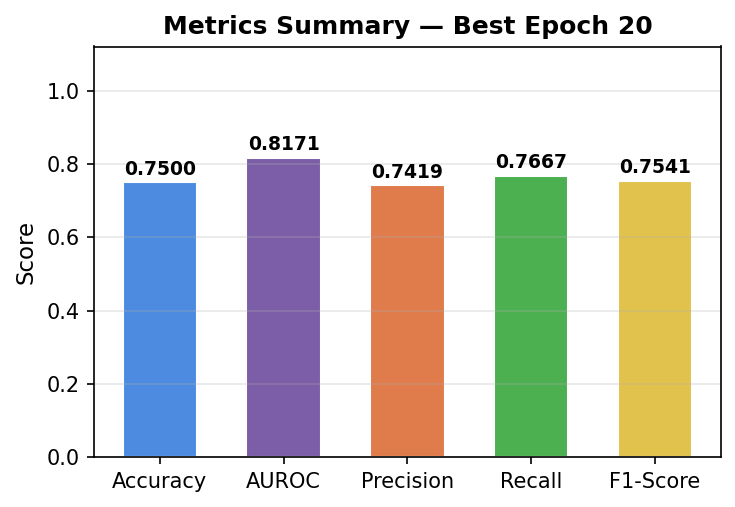

In [ ]:
# ── Metrics summary bar chart (best epoch 20) ────────────────────────────────
import matplotlib.pyplot as plt

names  = ['Accuracy', 'AUROC', 'Precision', 'Recall', 'F1-Score']
values = [0.7500,     0.8171,  23/31,       23/30,    2*(23/31)*(23/30)/((23/31)+(23/30))]
colors = ['#4C8BE0','#7B5EA7','#E07B4C','#4CAF50','#E0C24C']

fig, ax = plt.subplots(figsize=(6, 3.8))
bars = ax.bar(names, values, color=colors, edgecolor='white', width=0.6)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_ylim([0, 1.12])
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Metrics Summary — Best Epoch 20', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()
